# 🧬 CRISPR Off-Target Risk Prediction — Deep MLP (Dense Layers)

## Why Dense instead of CNN+LSTM for 893K rows?
| Model | Train speed | Best for |
|---|---|---|
| CNN+LSTM | Very slow (recurrence) | Small datasets, raw sequences only |
| **Deep MLP** | **Fast ✅** | **Large datasets with engineered features ✅** |

## Architecture
```
Input Branch 1 — gRNA Sequence (one-hot flattened: 20×4 = 80 dims)
   └─ Seq MLP: Dense(80→128)→BN→ReLU → Dense(128→128)→BN→ReLU → [128]

Input Branch 2 — Numeric Features (16 cols: mm0–mm3, gc_content, entropy...)
   └─ Num MLP: Dense(16→64)→BN→ReLU → Dense(64→128)→BN→ReLU  → [128]

Fusion [128 + 128 = 256]
   └─ Dense(256→256)→ReLU→Drop(0.4)
      Dense(256→128)→ReLU→Drop(0.3)
      Dense(128→64) →ReLU→Drop(0.2)
      Dense(64→1)   →Sigmoid → predicted risk_percentile / 100

Regression  → risk_percentile (0–100)
Classification → High (≥67) / Medium (33–67) / Low (<33)
```

## Cell 1 — Imports

In [1]:
# !pip install torch scikit-learn matplotlib pandas numpy seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Libraries loaded')
print(f'🖥️  Device : {device}')

✅ Libraries loaded
🖥️  Device : cpu


## Cell 2 — Load Data

In [2]:
df = pd.read_csv('features.csv', index_col=0)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(f'Dataset shape  : {df.shape}')
print(f'Columns        : {list(df.columns)}')
print(f'\nrisk_percentile stats:')
print(df['risk_percentile'].describe().round(3))

Dataset shape  : (893089, 20)
Columns        : ['gRNA', 'mm0', 'mm1', 'mm2', 'mm3', 'weighted_score', 'N_mut', 'risk_percentile', 'offtarget_class', 'gc_content', 'AT_content', 'effective_length', 'polyA_flag', 'polyT_flag', 'max_homopolymer_length', 'entropy', 'AA_freq', 'AT_freq', 'TA_freq', 'TT_freq']

risk_percentile stats:
count    893089.000
mean         50.000
std          28.397
min          13.525
25%          13.525
50%          54.793
75%          76.067
max         100.000
Name: risk_percentile, dtype: float64


## Cell 3 — Feature Engineering

In [3]:
NUMERIC_COLS = [
    'mm0', 'mm1', 'mm2', 'mm3', 'N_mut',
    'gc_content', 'AT_content', 'effective_length',
    'polyA_flag', 'polyT_flag', 'max_homopolymer_length',
    'entropy', 'AA_freq', 'AT_freq', 'TA_freq', 'TT_freq'
]

NUC_MAP = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

# ── gRNA: one-hot flatten → 20×4 = 80-dim vector ──────────────────────
# Flatten is fine for Dense layers (vs CNN which needs 2D spatial)
def encode_grna_flat(seqs, max_len=20):
    """Vectorised one-hot encoding → flattened (N, 80)"""
    N   = len(seqs)
    arr = np.zeros((N, max_len * 4), dtype=np.float32)
    for i, seq in enumerate(seqs):
        for j, c in enumerate(seq[:max_len]):
            if c in NUC_MAP:
                arr[i, j * 4 + NUC_MAP[c]] = 1.0
    return arr

print('Encoding gRNA sequences (flattened one-hot)...')
t0      = time.time()
seq_arr = encode_grna_flat(df['gRNA'].values)          # (N, 80)
print(f'✅ Sequence array : {seq_arr.shape}  ({time.time()-t0:.1f}s)')

# ── Numeric features ──────────────────────────────────────────────────
num_scaler = StandardScaler()
num_arr    = num_scaler.fit_transform(df[NUMERIC_COLS]).astype(np.float32)  # (N, 16)
print(f'✅ Numeric array  : {num_arr.shape}')

# ── Target: risk_percentile scaled to [0,1] ───────────────────────────
target_raw    = df['risk_percentile'].values.astype(np.float32)  # 0–100
target_scaled = target_raw / 100.0                               # 0–1

# ── Risk class labels ─────────────────────────────────────────────────
LOW_THR  = 33.0
HIGH_THR = 67.0

risk_labels = np.where(target_raw >= HIGH_THR, 2,
              np.where(target_raw >= LOW_THR,  1, 0)).astype(np.int64)

CLASS_NAMES = {0: 'Low', 1: 'Medium', 2: 'High'}
COLORS      = {0: '#4CAF50', 1: '#FFC107', 2: '#F44336'}

print(f'\nRisk thresholds  (risk_percentile):')
print(f'  🟢 Low    : < {LOW_THR}')
print(f'  🟡 Medium : {LOW_THR}–{HIGH_THR}')
print(f'  🔴 High   : ≥ {HIGH_THR}')
print(f'\nClass counts:')
for k, n in CLASS_NAMES.items():
    cnt = (risk_labels == k).sum()
    print(f'  {n:6s} : {cnt:,}  ({cnt/len(df)*100:.1f}%)')

Encoding gRNA sequences (flattened one-hot)...
✅ Sequence array : (893089, 80)  (1.7s)
✅ Numeric array  : (893089, 16)

Risk thresholds  (risk_percentile):
  🟢 Low    : < 33.0
  🟡 Medium : 33.0–67.0
  🔴 High   : ≥ 67.0

Class counts:
  Low    : 241,579  (27.0%)
  Medium : 376,610  (42.2%)
  High   : 274,900  (30.8%)


## Cell 4 — Train / Val / Test Split

In [4]:
idx = np.arange(len(df))

tr_idx, te_idx = train_test_split(idx, test_size=0.20, random_state=SEED,
                                   stratify=risk_labels)
tr_idx, va_idx = train_test_split(tr_idx, test_size=0.15, random_state=SEED,
                                   stratify=risk_labels[tr_idx])

print(f'Train : {len(tr_idx):,}  ({len(tr_idx)/len(df)*100:.1f}%)')
print(f'Val   : {len(va_idx):,}  ({len(va_idx)/len(df)*100:.1f}%)')
print(f'Test  : {len(te_idx):,}  ({len(te_idx)/len(df)*100:.1f}%)')

print('\nClass balance check (should be ~27/34/39% in each split):')
for name, split in [('Train', tr_idx), ('Val', va_idx), ('Test', te_idx)]:
    dist = ', '.join(f"{CLASS_NAMES[k]}: {(risk_labels[split]==k).mean()*100:.1f}%"
                     for k in [0, 1, 2])
    print(f'  {name:5s} → {dist}')

Train : 607,300  (68.0%)
Val   : 107,171  (12.0%)
Test  : 178,618  (20.0%)

Class balance check (should be ~27/34/39% in each split):
  Train → Low: 27.0%, Medium: 42.2%, High: 30.8%
  Val   → Low: 27.1%, Medium: 42.2%, High: 30.8%
  Test  → Low: 27.0%, Medium: 42.2%, High: 30.8%


## Cell 5 — PyTorch Dataset & DataLoader

In [5]:
class CRISPRDataset(Dataset):
    """
    seq    : (N, 80)   flattened one-hot gRNA
    num    : (N, 16)   scaled numeric features
    target : (N,)      risk_percentile / 100
    """
    def __init__(self, seq, num, target):
        self.seq    = torch.tensor(seq,    dtype=torch.float32)
        self.num    = torch.tensor(num,    dtype=torch.float32)
        self.target = torch.tensor(target, dtype=torch.float32)

    def __len__(self):
        return len(self.target)

    def __getitem__(self, i):
        return self.seq[i], self.num[i], self.target[i]


# Large batch size = fewer steps per epoch = faster training
BATCH_SIZE = 512

def make_loader(idxs, shuffle=True):
    ds = CRISPRDataset(seq_arr[idxs], num_arr[idxs], target_scaled[idxs])
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=0, pin_memory=False)

train_loader = make_loader(tr_idx, shuffle=True)
val_loader   = make_loader(va_idx, shuffle=False)
test_loader  = make_loader(te_idx, shuffle=False)

print(f'✅ DataLoaders ready  (batch_size={BATCH_SIZE})')
s, n, t = next(iter(train_loader))
print(f'   Seq  shape : {s.shape}   (batch, 80)')
print(f'   Num  shape : {n.shape}   (batch, 16)')
print(f'   Target range: [{t.min():.3f}, {t.max():.3f}]')
print(f'   Batches/epoch: {len(train_loader):,}')

✅ DataLoaders ready  (batch_size=512)
   Seq  shape : torch.Size([512, 80])   (batch, 80)
   Num  shape : torch.Size([512, 16])   (batch, 16)
   Target range: [0.135, 1.000]
   Batches/epoch: 1,187


## Cell 6 — Deep MLP Model

In [6]:
class ResidualBlock(nn.Module):
    """Dense residual block: skip connection helps gradient flow in deep MLPs."""
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))   # skip connection


class CRISPRDeepMLP(nn.Module):
    """
    Deep MLP with two input branches + residual fusion
    ==================================================
    Branch 1 — Sequence  (B, 80)  flattened one-hot gRNA
      Linear(80→128) → BN → ReLU
      Linear(128→128)→ BN → ReLU  [ResidualBlock]
      → [128]

    Branch 2 — Numerics  (B, 16)
      Linear(16→64)  → BN → ReLU
      Linear(64→128) → BN → ReLU
      → [128]

    Fusion  (B, 256)
      ResidualBlock(256) × 2
      Linear(256→128) → ReLU → Dropout(0.3)
      Linear(128→64)  → ReLU → Dropout(0.2)
      Linear(64→1)    → Sigmoid  →  output in (0,1)
    """

    def __init__(self, seq_dim=80, num_dim=16, dropout=0.3):
        super().__init__()

        # ── Sequence branch ───────────────────────────────────────────
        self.seq_branch = nn.Sequential(
            nn.Linear(seq_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            ResidualBlock(128, dropout=dropout),
        )  # → (B, 128)

        # ── Numeric branch ────────────────────────────────────────────
        self.num_branch = nn.Sequential(
            nn.Linear(num_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )  # → (B, 128)

        # ── Fusion ────────────────────────────────────────────────────
        self.fusion = nn.Sequential(
            ResidualBlock(256, dropout=0.4),
            ResidualBlock(256, dropout=0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()            # clamps output to (0,1)
        )

    def forward(self, seq, num):
        seq_feat = self.seq_branch(seq)                          # (B, 128)
        num_feat = self.num_branch(num)                          # (B, 128)
        fused    = torch.cat([seq_feat, num_feat], dim=1)        # (B, 256)
        return self.fusion(fused).squeeze(-1)                    # (B,)


model = CRISPRDeepMLP(
    seq_dim = 80,
    num_dim = len(NUMERIC_COLS),
    dropout = 0.3
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model  : CRISPRDeepMLP')
print(f'Params : {total_params:,}')
print()

# Quick forward pass test
with torch.no_grad():
    test_out = model(s.to(device), n.to(device))
print(f'Output shape : {test_out.shape}')
print(f'Output range : [{test_out.min():.4f}, {test_out.max():.4f}]  ← must be (0,1) ✅')

Model  : CRISPRDeepMLP
Params : 360,385

Output shape : torch.Size([512])
Output range : [0.3828, 0.6194]  ← must be (0,1) ✅


## Cell 7 — Training Config

In [7]:
EPOCHS  = 30       # MLP converges fast on large data — 30 usually enough
LR      = 1e-3
WD      = 1e-4

criterion = nn.HuberLoss(delta=0.1)     # robust to outliers
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print(f'Loss      : HuberLoss(delta=0.1)')
print(f'Optimizer : Adam  (lr={LR}, wd={WD})')
print(f'Scheduler : ReduceLROnPlateau  (factor=0.5, patience=3)')
print(f'Epochs    : {EPOCHS}   |   Batch size: {BATCH_SIZE}')
print(f'Batches/epoch : {len(train_loader):,}')

Loss      : HuberLoss(delta=0.1)
Optimizer : Adam  (lr=0.001, wd=0.0001)
Scheduler : ReduceLROnPlateau  (factor=0.5, patience=3)
Epochs    : 30   |   Batch size: 512
Batches/epoch : 1,187


## Cell 8 — Training Loop

In [8]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for seq, num, tgt in loader:
        seq, num, tgt = seq.to(device), num.to(device), tgt.to(device)
        optimizer.zero_grad()
        pred = model(seq, num)
        loss = criterion(pred, tgt)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(tgt)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    preds_list, tgts_list = [], []
    for seq, num, tgt in loader:
        seq, num, tgt = seq.to(device), num.to(device), tgt.to(device)
        pred = model(seq, num)
        total_loss += criterion(pred, tgt).item() * len(tgt)
        preds_list.append(pred.cpu().numpy())
        tgts_list.append(tgt.cpu().numpy())
    return (total_loss / len(loader.dataset),
            np.concatenate(preds_list),
            np.concatenate(tgts_list))


# ── Training loop ─────────────────────────────────────────────────────
train_losses, val_losses, val_r2s = [], [], []
best_val_loss = float('inf')
best_state    = None
patience      = 8
no_improve    = 0

print(f"{'─'*65}")
print(f'  Training  ({EPOCHS} epochs | early stop patience={patience})')
print(f"{'─'*65}")

for epoch in range(1, EPOCHS + 1):
    t_start  = time.time()
    tr_loss  = train_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_preds, va_tgts = eval_epoch(model, val_loader, criterion)
    elapsed  = time.time() - t_start

    # Compute R² in percentile space (×100) for readability
    va_r2 = r2_score(va_tgts * 100, va_preds * 100)
    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    val_r2s.append(va_r2)

    scheduler.step(va_loss)

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve    = 0
        flag = '✅'
    else:
        no_improve += 1
        flag = ''

    lr_now = optimizer.param_groups[0]['lr']
    print(f'  Ep {epoch:3d}/{EPOCHS} | '
          f'Train: {tr_loss:.5f} | '
          f'Val: {va_loss:.5f} | '
          f'R²: {va_r2:.4f} | '
          f'LR: {lr_now:.1e} | '
          f'{elapsed:.0f}s {flag}')

    if no_improve >= patience:
        print(f'\n  ⏹ Early stopping at epoch {epoch}')
        break

model.load_state_dict(best_state)
print(f'\n  ✅ Best Val Loss: {best_val_loss:.5f}')

─────────────────────────────────────────────────────────────────
  Training  (30 epochs | early stop patience=8)
─────────────────────────────────────────────────────────────────
  Ep   1/30 | Train: 0.00678 | Val: 0.00811 | R²: 0.7191 | LR: 1.0e-03 | 20s ✅
  Ep   2/30 | Train: 0.00257 | Val: 0.00174 | R²: 0.9521 | LR: 1.0e-03 | 24s ✅
  Ep   3/30 | Train: 0.00204 | Val: 0.01114 | R²: 0.5923 | LR: 1.0e-03 | 54s 
  Ep   4/30 | Train: 0.00191 | Val: 0.00514 | R²: 0.8523 | LR: 1.0e-03 | 348s 
  Ep   5/30 | Train: 0.00174 | Val: 0.00964 | R²: 0.6827 | LR: 1.0e-03 | 558s 
  Ep   6/30 | Train: 0.00170 | Val: 0.00788 | R²: 0.7470 | LR: 5.0e-04 | 637s 
  Ep   7/30 | Train: 0.00127 | Val: 0.00829 | R²: 0.7178 | LR: 5.0e-04 | 584s 
  Ep   8/30 | Train: 0.00125 | Val: 0.00357 | R²: 0.8967 | LR: 5.0e-04 | 545s 
  Ep   9/30 | Train: 0.00125 | Val: 0.00137 | R²: 0.9606 | LR: 5.0e-04 | 590s ✅
  Ep  10/30 | Train: 0.00121 | Val: 0.00220 | R²: 0.9417 | LR: 5.0e-04 | 658s 
  Ep  11/30 | Train: 0.00123 |

## Cell 9 — Training Curves

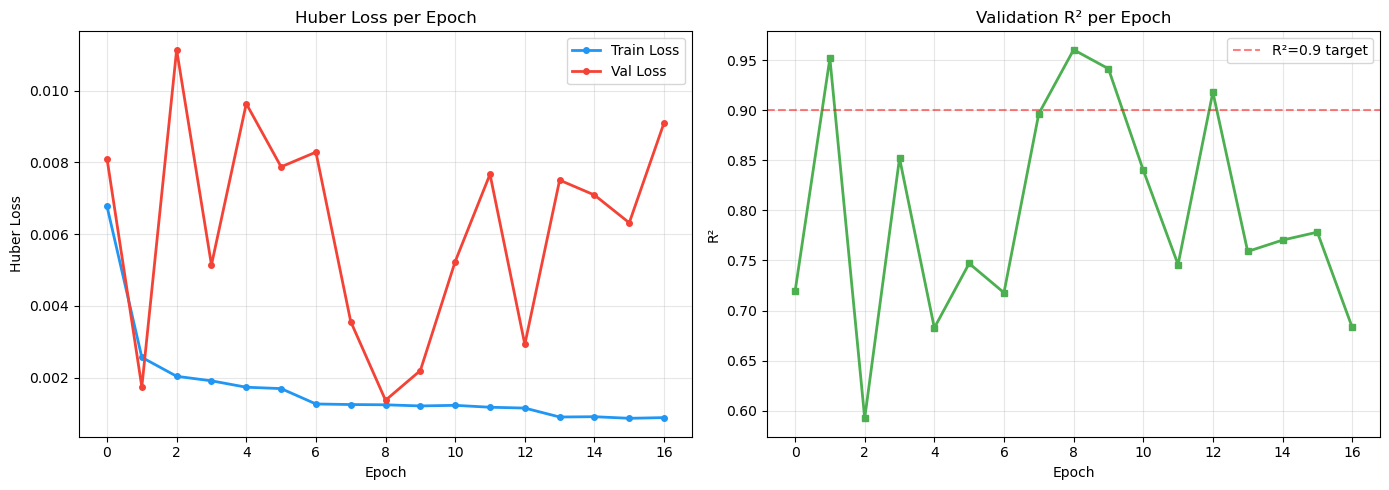

Saved: 01_training_curves.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss', color='#2196F3', lw=2, marker='o', ms=4)
axes[0].plot(val_losses,   label='Val Loss',   color='#F44336', lw=2, marker='o', ms=4)
axes[0].set(title='Huber Loss per Epoch', xlabel='Epoch', ylabel='Huber Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(val_r2s, color='#4CAF50', lw=2, marker='s', ms=4)
axes[1].axhline(0.9, color='red', ls='--', alpha=0.5, label='R²=0.9 target')
axes[1].set(title='Validation R² per Epoch', xlabel='Epoch', ylabel='R²')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('01_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_training_curves.png')

## Cell 10 — Regression Evaluation on Test Set

  Regression Metrics — Test Set
  Target: risk_percentile  (0–100 scale)
  RMSE : 5.6887  percentile points
  MAE  : 3.5410  percentile points
  R²   : 0.9598


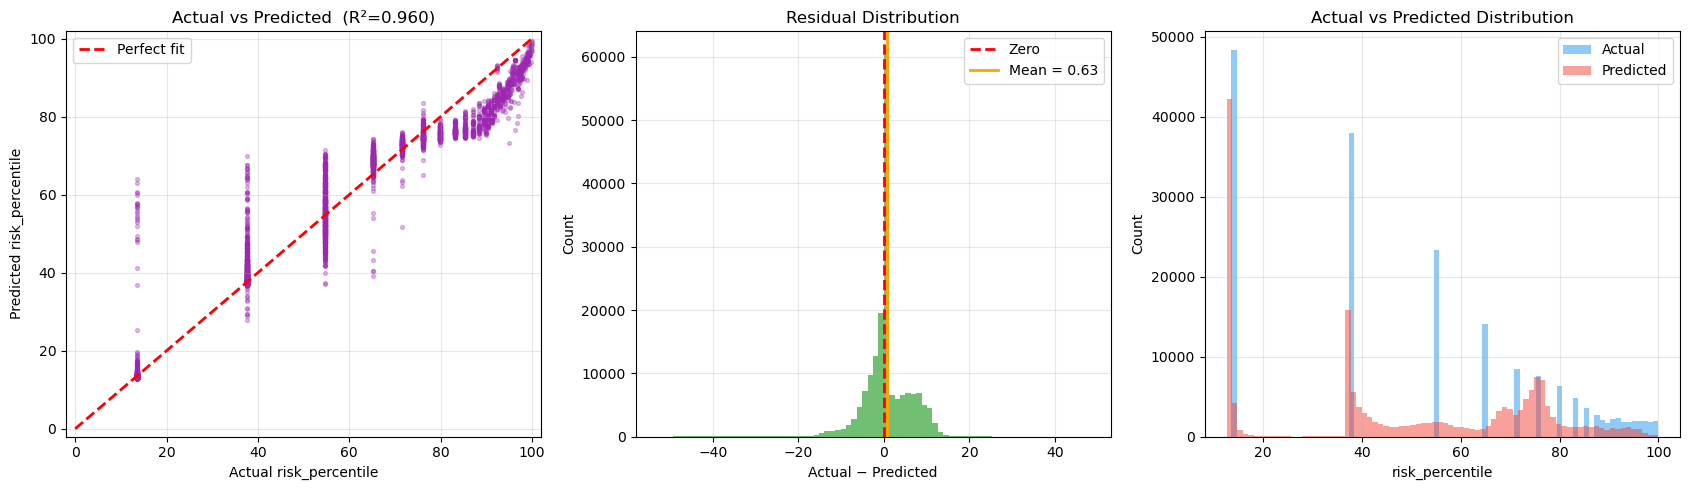

Saved: 02_regression_results.png


In [10]:
_, preds_scaled, targs_scaled = eval_epoch(model, test_loader, criterion)

# Back to percentile space
preds_pct = preds_scaled * 100
targs_pct = targs_scaled * 100

rmse = np.sqrt(mean_squared_error(targs_pct, preds_pct))
mae  = mean_absolute_error(targs_pct, preds_pct)
r2   = r2_score(targs_pct, preds_pct)

print('='*50)
print('  Regression Metrics — Test Set')
print('  Target: risk_percentile  (0–100 scale)')
print('='*50)
print(f'  RMSE : {rmse:.4f}  percentile points')
print(f'  MAE  : {mae:.4f}  percentile points')
print(f'  R²   : {r2:.4f}')
print('='*50)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Actual vs Predicted (sample 5K for plot speed)
s_idx = np.random.choice(len(targs_pct), min(5000, len(targs_pct)), replace=False)
axes[0].scatter(targs_pct[s_idx], preds_pct[s_idx], alpha=0.3, s=8, color='#9C27B0')
axes[0].plot([0,100],[0,100], 'r--', lw=2, label='Perfect fit')
axes[0].set(title=f'Actual vs Predicted  (R²={r2:.3f})',
            xlabel='Actual risk_percentile',
            ylabel='Predicted risk_percentile',
            xlim=[-2,102], ylim=[-2,102])
axes[0].legend(); axes[0].grid(alpha=0.3)

# Residuals histogram
residuals = targs_pct - preds_pct
axes[1].hist(residuals, bins=80, color='#4CAF50', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='red', lw=2, ls='--', label='Zero')
axes[1].axvline(residuals.mean(), color='orange', lw=2,
                label=f'Mean = {residuals.mean():.2f}')
axes[1].set(title='Residual Distribution',
            xlabel='Actual − Predicted', ylabel='Count')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Distribution overlap
axes[2].hist(targs_pct, bins=80, alpha=0.5, color='#2196F3', label='Actual',    edgecolor='none')
axes[2].hist(preds_pct, bins=80, alpha=0.5, color='#F44336', label='Predicted', edgecolor='none')
axes[2].set(title='Actual vs Predicted Distribution',
            xlabel='risk_percentile', ylabel='Count')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('02_regression_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_regression_results.png')

## Cell 11 — Risk Classification (High / Medium / Low)

Risk Thresholds:
  🟢 Low    : risk_percentile < 33.0
  🟡 Medium : 33.0–67.0
  🔴 High   : ≥ 67.0

              precision    recall  f1-score   support

         Low       0.99      0.99      0.99     48316
      Medium       0.99      0.83      0.90     75322
        High       0.81      1.00      0.89     54980

    accuracy                           0.92    178618
   macro avg       0.93      0.94      0.93    178618
weighted avg       0.93      0.92      0.92    178618



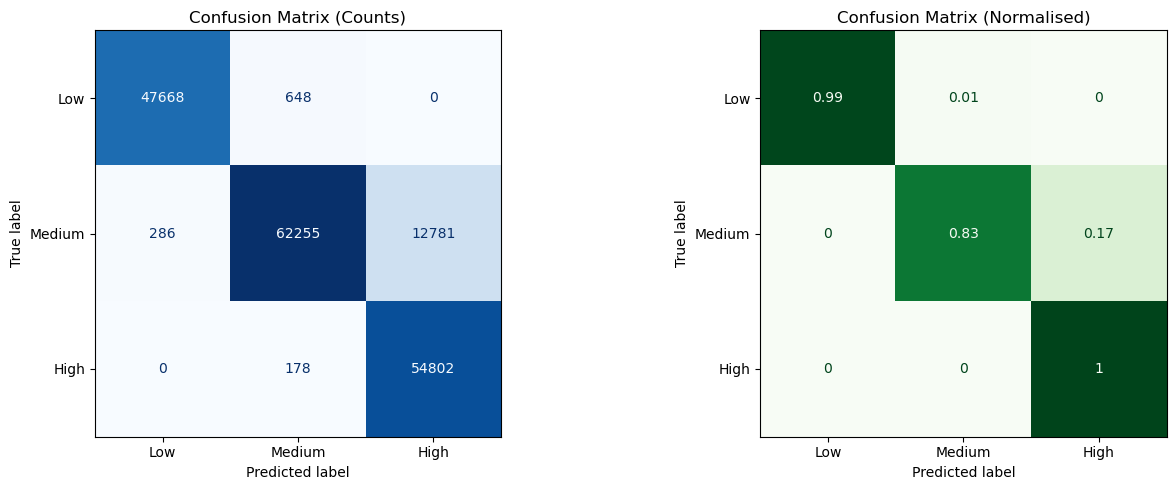

Saved: 03_confusion_matrix.png


In [11]:
def to_class(pct, lo=LOW_THR, hi=HIGH_THR):
    return np.where(pct >= hi, 2, np.where(pct >= lo, 1, 0)).astype(int)

y_true_cls = to_class(targs_pct)
y_pred_cls = to_class(preds_pct)
accuracy   = (y_true_cls == y_pred_cls).mean() * 100

print(f'Risk Thresholds:')
print(f'  🟢 Low    : risk_percentile < {LOW_THR}')
print(f'  🟡 Medium : {LOW_THR}–{HIGH_THR}')
print(f'  🔴 High   : ≥ {HIGH_THR}\n')
print(classification_report(y_true_cls, y_pred_cls,
                             target_names=['Low', 'Medium', 'High']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_true_cls, y_pred_cls)
ConfusionMatrixDisplay(cm, display_labels=['Low','Medium','High']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Counts)')

cm_n = confusion_matrix(y_true_cls, y_pred_cls, normalize='true')
ConfusionMatrixDisplay(np.round(cm_n, 2),
                       display_labels=['Low','Medium','High']).plot(
    ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Confusion Matrix (Normalised)')

plt.tight_layout()
plt.savefig('03_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_confusion_matrix.png')

## Cell 12 — Risk Distribution & Feature Importance

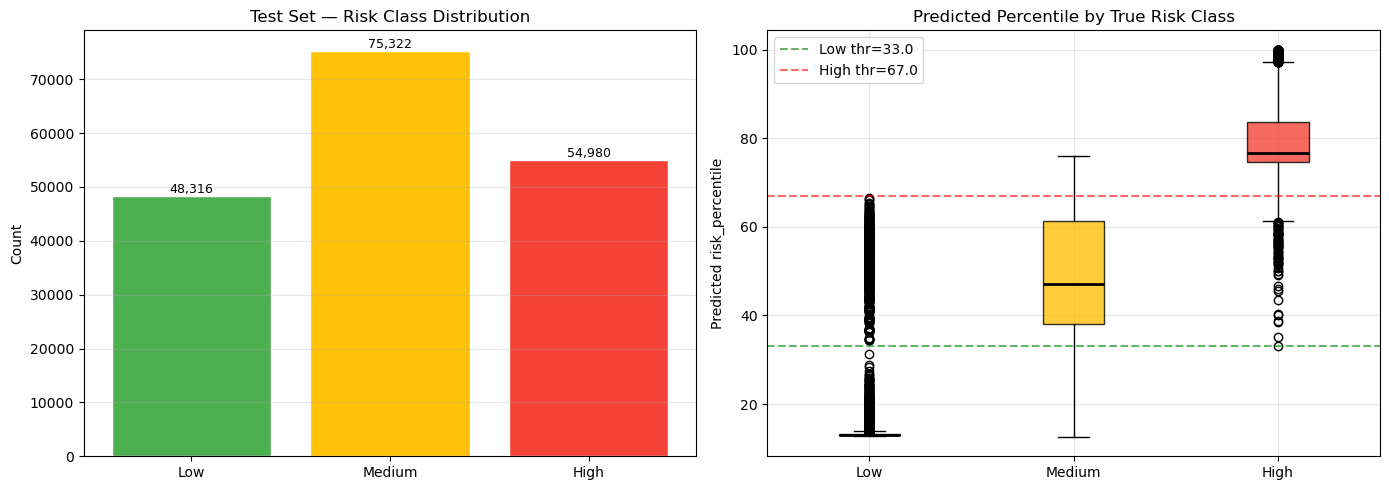

Saved: 04_risk_distribution.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

u, c = np.unique(y_true_cls, return_counts=True)
axes[0].bar([CLASS_NAMES[x] for x in u], c,
            color=[COLORS[x] for x in u], edgecolor='white')
for x, cnt in zip(u, c):
    axes[0].text(CLASS_NAMES[x], cnt + 500, f'{cnt:,}', ha='center', fontsize=9)
axes[0].set(title='Test Set — Risk Class Distribution', ylabel='Count')
axes[0].grid(axis='y', alpha=0.3)

# Boxplot: predicted pct per true class
bp = axes[1].boxplot([preds_pct[y_true_cls==k] for k in [0,1,2]],
                     patch_artist=True, labels=['Low','Medium','High'],
                     medianprops={'color':'black','linewidth':2})
for patch, k in zip(bp['boxes'], [0,1,2]):
    patch.set_facecolor(COLORS[k]); patch.set_alpha(0.8)
axes[1].axhline(LOW_THR,  color='green', ls='--', alpha=0.6, label=f'Low thr={LOW_THR}')
axes[1].axhline(HIGH_THR, color='red',   ls='--', alpha=0.6, label=f'High thr={HIGH_THR}')
axes[1].set(title='Predicted Percentile by True Risk Class',
            ylabel='Predicted risk_percentile')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('04_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_risk_distribution.png')

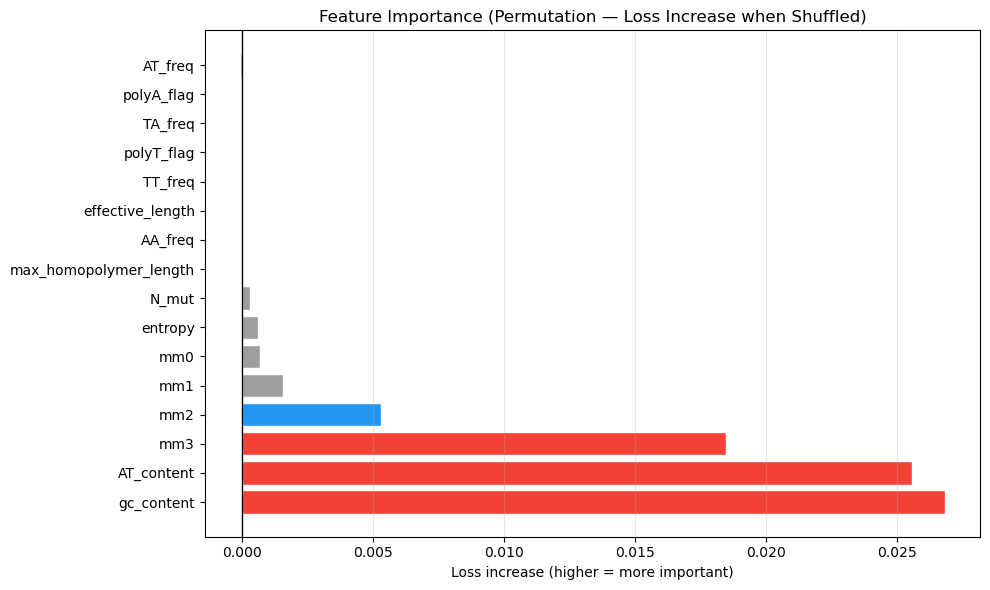

Saved: 05_feature_importance.png

Top 5 most important features:
  gc_content                    : +0.02681
  AT_content                    : +0.02555
  mm3                           : +0.01845
  mm2                           : +0.00529
  mm1                           : +0.00158


In [13]:
# Feature importance: permutation-based (more reliable than correlation)
# Shuffle each feature and measure how much loss increases
model.eval()
s_idx   = np.random.choice(len(te_idx), min(5000, len(te_idx)), replace=False)
sample_seq = torch.tensor(seq_arr[te_idx[s_idx]], dtype=torch.float32).to(device)
sample_num = torch.tensor(num_arr[te_idx[s_idx]], dtype=torch.float32).to(device)
sample_tgt = torch.tensor(target_scaled[te_idx[s_idx]], dtype=torch.float32).to(device)

with torch.no_grad():
    base_loss = criterion(model(sample_seq, sample_num), sample_tgt).item()

importances = []
for j in range(len(NUMERIC_COLS)):
    perm_num = sample_num.clone()
    perm_num[:, j] = perm_num[torch.randperm(len(perm_num)), j]  # shuffle column
    with torch.no_grad():
        perm_loss = criterion(model(sample_seq, perm_num), sample_tgt).item()
    importances.append(perm_loss - base_loss)

importances = np.array(importances)
order       = np.argsort(importances)[::-1]

bar_colors = ['#F44336' if v > 0.01 else '#2196F3' if v > 0.005 else '#9E9E9E'
              for v in importances[order]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([NUMERIC_COLS[i] for i in order], importances[order],
        color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set(title='Feature Importance (Permutation — Loss Increase when Shuffled)',
       xlabel='Loss increase (higher = more important)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_feature_importance.png')
print('\nTop 5 most important features:')
for i in order[:5]:
    print(f'  {NUMERIC_COLS[i]:30s}: +{importances[i]:.5f}')

## Cell 13 — Save Predictions CSV

In [14]:
out_df = df.iloc[te_idx].copy().reset_index(drop=True)
out_df['predicted_percentile'] = np.round(preds_pct, 2)
out_df['actual_percentile']    = np.round(targs_pct, 2)
out_df['predicted_risk']       = [CLASS_NAMES[c] for c in y_pred_cls]
out_df['actual_risk']          = [CLASS_NAMES[c] for c in y_true_cls]
out_df['correct']              = out_df['predicted_risk'] == out_df['actual_risk']

out_df.to_csv('predictions.csv', index=False)
acc = out_df['correct'].mean() * 100
print(f'✅ Saved: predictions.csv')
print(f'   Total samples : {len(out_df):,}')
print(f'   Accuracy      : {acc:.2f}%\n')
out_df[['gRNA','actual_percentile','predicted_percentile',
        'actual_risk','predicted_risk','correct']].head(10)

✅ Saved: predictions.csv
   Total samples : 178,618
   Accuracy      : 92.22%



,gRNA,actual_percentile,predicted_percentile,actual_risk,predicted_risk,correct
0,TTTACTTTGGCTCATAGAAT,65.290001,69.320000,Medium,High,False
1,GTCTACGTACTTTGGTTATC,13.520000,13.190000,Low,Low,True
2,CTATAGTGGGGAAGATTGGA,13.520000,13.170000,Low,Low,True
3,CCAAATTTGGACAGTTAGCT,37.639999,37.570000,Medium,Medium,True
4,AAAAAGGTTATCTTCGCTAG,13.520000,14.420000,Low,Low,True
5,CAGGGTGATCACAGGAATAT,13.520000,13.310000,Low,Low,True
6,TTTCCACATTTACTGAATTT,79.959999,74.919998,High,High,True
7,CTAGAAAATAAATGACGGTG,37.639999,45.980000,Medium,Medium,True
8,GGATTTCGCTACAAGAGAAT,37.639999,37.900002,Medium,Medium,True
9,GTTTAAGTTCGAGGATAATT,13.520000,13.620000,Low,Low,True


## Cell 14 — Predict on New gRNA

In [15]:
def predict_risk(grna_seq, numeric_features_dict):
    """
    Predict off-target risk for one new gRNA.

    Parameters
    ----------
    grna_seq : str   20-nt gRNA (A/C/G/T)
    numeric_features_dict : dict  keys = NUMERIC_COLS

    Returns
    -------
    dict with predicted_percentile, risk_class, interpretation
    """
    # Encode sequence (flattened one-hot)
    enc = np.zeros((1, 80), dtype=np.float32)
    for j, c in enumerate(grna_seq[:20]):
        if c in NUC_MAP:
            enc[0, j * 4 + NUC_MAP[c]] = 1.0
    seq_t = torch.tensor(enc, dtype=torch.float32).to(device)

    # Scale numerics
    num_vals = np.array([[numeric_features_dict[c] for c in NUMERIC_COLS]], dtype=np.float32)
    num_t    = torch.tensor(num_scaler.transform(num_vals), dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        pred_scaled = float(model(seq_t, num_t).item())

    pred_pct  = float(np.clip(pred_scaled * 100, 0, 100))
    risk_code = int(to_class(np.array([pred_pct]))[0])
    risk_name = CLASS_NAMES[risk_code]

    msg = {
        0: '🟢 Low risk — safe to proceed',
        1: '🟡 Medium risk — experimental validation recommended',
        2: '🔴 High risk — redesign or validate carefully'
    }[risk_code]

    return {
        'gRNA'                 : grna_seq,
        'predicted_percentile' : round(pred_pct, 2),
        'risk_class'           : risk_name,
        'interpretation'       : msg
    }


# Test on a sample row
sample     = df.iloc[0]
result     = predict_risk(sample['gRNA'], {c: sample[c] for c in NUMERIC_COLS})
print('Example prediction:')
for k, v in result.items():
    print(f'  {k:25s}: {v}')

Example prediction:
  gRNA                     : AAAAAAAAAAAAAAAAAAAA
  predicted_percentile     : 100.0
  risk_class               : High
  interpretation           : 🔴 High risk — redesign or validate carefully


## Cell 15 — Final Summary

In [16]:
print('=' * 58)
print('  CRISPR OFF-TARGET RISK — DEEP MLP SUMMARY')
print('=' * 58)
print(f'  Architecture  : Deep MLP  (Dual-branch + Residual blocks)')
print(f'  Parameters    : {total_params:,}')
print(f'  Training rows : {len(tr_idx):,}')
print()
print(f'  ── Regression (risk_percentile 0–100) ──')
print(f'  RMSE     : {rmse:.4f} percentile points')
print(f'  MAE      : {mae:.4f} percentile points')
print(f'  R²       : {r2:.4f}')
print()
print(f'  ── Classification ──')
print(f'  Accuracy : {accuracy:.2f}%')
print()
print(f'  ── Risk Thresholds ──')
print(f'  🟢 Low    : risk_percentile < {LOW_THR}')
print(f'  🟡 Medium : {LOW_THR}–{HIGH_THR}')
print(f'  🔴 High   : ≥ {HIGH_THR}')
print('=' * 58)

  CRISPR OFF-TARGET RISK — DEEP MLP SUMMARY
  Architecture  : Deep MLP  (Dual-branch + Residual blocks)
  Parameters    : 360,385
  Training rows : 607,300

  ── Regression (risk_percentile 0–100) ──
  RMSE     : 5.6887 percentile points
  MAE      : 3.5410 percentile points
  R²       : 0.9598

  ── Classification ──
  Accuracy : 92.22%

  ── Risk Thresholds ──
  🟢 Low    : risk_percentile < 33.0
  🟡 Medium : 33.0–67.0
  🔴 High   : ≥ 67.0
